## 1. Environment Setup & Data Loading

In [74]:
import pandas as pd
import numpy as np
import networkx as nx
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score

print("Imports successful!")

Imports successful!


In [75]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
edges_df = pd.read_csv('txs_edgelist.csv')

# Keep only labeled transactions
train_labeled = train_df[train_df['label'].isin(['0', '1', 0, 1])].copy()
train_labeled['label'] = train_labeled['label'].astype(int)

print(f"Train labeled shape: {train_labeled.shape}")
print(f"Test shape: {test_df.shape}")

Train labeled shape: (31235, 168)
Test shape: (15329, 168)


## 2. Graph Topology & Feature Engineering

In [76]:
print("Calculating high-signal graph metrics & targeted 1-hop statistics...")

# 1. Directed & Undirected Graph Construction
G = nx.from_pandas_edgelist(edges_df, source='txId1', target='txId2', create_using=nx.DiGraph())
G_undirected = G.to_undirected()

# Node degree dictionaries & centrality
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())
pagerank = nx.pagerank(G, alpha=0.85)
clustering_coef = nx.clustering(G_undirected)

# 2. Extract 1-Hop Neighbor Means for TOP 15 Features Only (Reduces Noise)
top_feat_cols = [f'feat_{i}' for i in range(1, 16)]
all_nodes_df = pd.concat([train_df, test_df], ignore_index=True)
feature_lookup = all_nodes_df.set_index('txId')[top_feat_cols]

# Map incoming features to target nodes
in_edges = edges_df.merge(feature_lookup, left_on='txId1', right_index=True)
in_neighbor_means = in_edges.groupby('txId2')[top_feat_cols].mean().add_prefix('in_neigh_mean_')

# Map outgoing features to source nodes
out_edges = edges_df.merge(feature_lookup, left_on='txId2', right_index=True)
out_neighbor_means = out_edges.groupby('txId1')[top_feat_cols].mean().add_prefix('out_neigh_mean_')

# 3. Master Feature Generation Function
def create_advanced_features(df):
    df = df.copy()
    
    # Structural Topology
    df['in_degree'] = df['txId'].map(in_degrees).fillna(0)
    df['out_degree'] = df['txId'].map(out_degrees).fillna(0)
    df['total_degree'] = df['in_degree'] + df['out_degree']
    df['degree_ratio'] = (df['in_degree'] + 1) / (df['out_degree'] + 1)
    df['degree_diff'] = df['in_degree'] - df['out_degree']
    df['degree_imbalance'] = (df['in_degree'] - df['out_degree']) / (df['total_degree'] + 1)
    df['pagerank'] = df['txId'].map(pagerank).fillna(0)
    df['clustering_coef'] = df['txId'].map(clustering_coef).fillna(0)
    
    # Merge 1-hop neighborhood aggregations
    df = df.merge(in_neighbor_means, left_on='txId', right_index=True, how='left')
    df = df.merge(out_neighbor_means, left_on='txId', right_index=True, how='left')
    df = df.fillna(0)
    
    # Differential Features (Local value minus neighbor average)
    for col in ['feat_1', 'feat_2', 'feat_3']:
        if f'in_neigh_mean_{col}' in df.columns:
            df[f'{col}_diff_in_neigh'] = df[col] - df[f'in_neigh_mean_{col}']
        if f'out_neigh_mean_{col}' in df.columns:
            df[f'{col}_diff_out_neigh'] = df[col] - df[f'out_neigh_mean_{col}']
            
    return df

# Generate upgraded feature tables
train_features = create_advanced_features(train_labeled)
test_features = create_advanced_features(test_df)

print(f"Total engineered features: {train_features.shape[1] - 4}")

Calculating high-signal graph metrics & targeted 1-hop statistics...
Total engineered features: 208


## 3. Out-of-Time Cross Validation Strategy

In [77]:
from xgboost import XGBClassifier
from scipy.stats import rankdata

ignore_cols = ['index', 'txId', 'label', 'time_step']
feature_cols = [c for c in train_features.columns if c not in ignore_cols]

# Sort by time_step for out-of-time evaluation
train_features = train_features.sort_values('time_step').reset_index(drop=True)

X = train_features[feature_cols]
y = train_features['label']

tscv = TimeSeriesSplit(n_splits=5)
lgb_scores, cat_scores, xgb_scores, ensemble_scores = [], [], [], []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
    scale_pos_weight = (len(y_tr) - sum(y_tr)) / max(sum(y_tr), 1)
    
    # 1. LightGBM
    lgb_model = LGBMClassifier(
        n_estimators=450,
        learning_rate=0.02,
        num_leaves=31,
        max_depth=6,
        colsample_bytree=0.8,
        subsample=0.8,
        scale_pos_weight=scale_pos_weight * 0.7,
        random_state=42,
        verbose=-1
    )
    lgb_model.fit(X_tr, y_tr)
    lgb_preds = lgb_model.predict_proba(X_val)[:, 1]
    
    # 2. CatBoost
    cat_model = CatBoostClassifier(
        iterations=450,
        learning_rate=0.02,
        depth=6,
        l2_leaf_reg=4.0,
        auto_class_weights='Balanced',
        random_seed=42,
        verbose=0
    )
    cat_model.fit(X_tr, y_tr)
    cat_preds = cat_model.predict_proba(X_val)[:, 1]
    
    # 3. XGBoost
    xgb_model = XGBClassifier(
        n_estimators=400,
        learning_rate=0.02,
        max_depth=5,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight * 0.7,
        random_state=42,
        eval_metric='auc'
    )
    xgb_model.fit(X_tr, y_tr)
    xgb_preds = xgb_model.predict_proba(X_val)[:, 1]
    
    # Rank Averaging Blending (Convert to percentile rank before weighting)
    r_lgb = rankdata(lgb_preds) / len(lgb_preds)
    r_cat = rankdata(cat_preds) / len(cat_preds)
    r_xgb = rankdata(xgb_preds) / len(xgb_preds)
    
    blend_preds = (0.50 * r_lgb) + (0.40 * r_cat) + (0.10 * r_xgb)
    
    lgb_auc = roc_auc_score(y_val, lgb_preds)
    cat_auc = roc_auc_score(y_val, cat_preds)
    xgb_auc = roc_auc_score(y_val, xgb_preds)
    blend_auc = roc_auc_score(y_val, blend_preds)
    
    lgb_scores.append(lgb_auc)
    cat_scores.append(cat_auc)
    xgb_scores.append(xgb_auc)
    ensemble_scores.append(blend_auc)
    
    print(f"Fold {fold+1} | LGB: {lgb_auc:.5f} | CatBoost: {cat_auc:.5f} | XGB: {xgb_auc:.5f} | Blend: {blend_auc:.5f}")

print(f"\nMean Ensemble CV ROC-AUC: {np.mean(ensemble_scores):.5f}")

Fold 1 | LGB: 0.92482 | CatBoost: 0.90967 | XGB: 0.94479 | Blend: 0.93450
Fold 2 | LGB: 0.99747 | CatBoost: 0.99723 | XGB: 0.99698 | Blend: 0.99770
Fold 3 | LGB: 0.98751 | CatBoost: 0.99116 | XGB: 0.98027 | Blend: 0.99127
Fold 4 | LGB: 0.88386 | CatBoost: 0.83856 | XGB: 0.87810 | Blend: 0.87146
Fold 5 | LGB: 0.99700 | CatBoost: 0.99578 | XGB: 0.98914 | Blend: 0.99661

Mean Ensemble CV ROC-AUC: 0.95831


## 4. Final Model Ensemble & Submission

In [78]:
scale_pos_weight_full = (len(y) - sum(y)) / max(sum(y), 1)

print("Training final LightGBM model...")
final_lgb = LGBMClassifier(
    n_estimators=450,
    learning_rate=0.02,
    num_leaves=31,
    max_depth=6,
    colsample_bytree=0.8,
    subsample=0.8,
    scale_pos_weight=scale_pos_weight_full * 0.7,
    random_state=42,
    verbose=-1
)
final_lgb.fit(X, y)

print("Training final CatBoost model...")
final_cat = CatBoostClassifier(
    iterations=450,
    learning_rate=0.02,
    depth=6,
    l2_leaf_reg=4.0,
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=0
)
final_cat.fit(X, y)

print("Training final XGBoost model...")
final_xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.02,
    max_depth=5,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight_full * 0.7,
    random_state=42,
    eval_metric='auc'
)
final_xgb.fit(X, y)

# Predict test set probabilities
lgb_test_preds = final_lgb.predict_proba(test_features[feature_cols])[:, 1]
cat_test_preds = final_cat.predict_proba(test_features[feature_cols])[:, 1]
xgb_test_preds = final_xgb.predict_proba(test_features[feature_cols])[:, 1]

# Convert predictions to rank percentiles [0.0 to 1.0]
r_lgb_test = rankdata(lgb_test_preds) / len(lgb_test_preds)
r_cat_test = rankdata(cat_test_preds) / len(cat_test_preds)
r_xgb_test = rankdata(xgb_test_preds) / len(xgb_test_preds)

# Weighted Rank Blend
final_test_preds = (0.50 * r_lgb_test) + (0.40 * r_cat_test) + (0.10 * r_xgb_test)

# Format & save submission
submission = pd.DataFrame({
    'index': test_df['index'],
    'target': final_test_preds
})

submission.to_csv('submission.csv', index=False)
print("Updated submission.csv successfully generated and saved!")

Training final LightGBM model...
Training final CatBoost model...
Training final XGBoost model...
Updated submission.csv successfully generated and saved!


## 5. Feature Importance & Model Interpretation

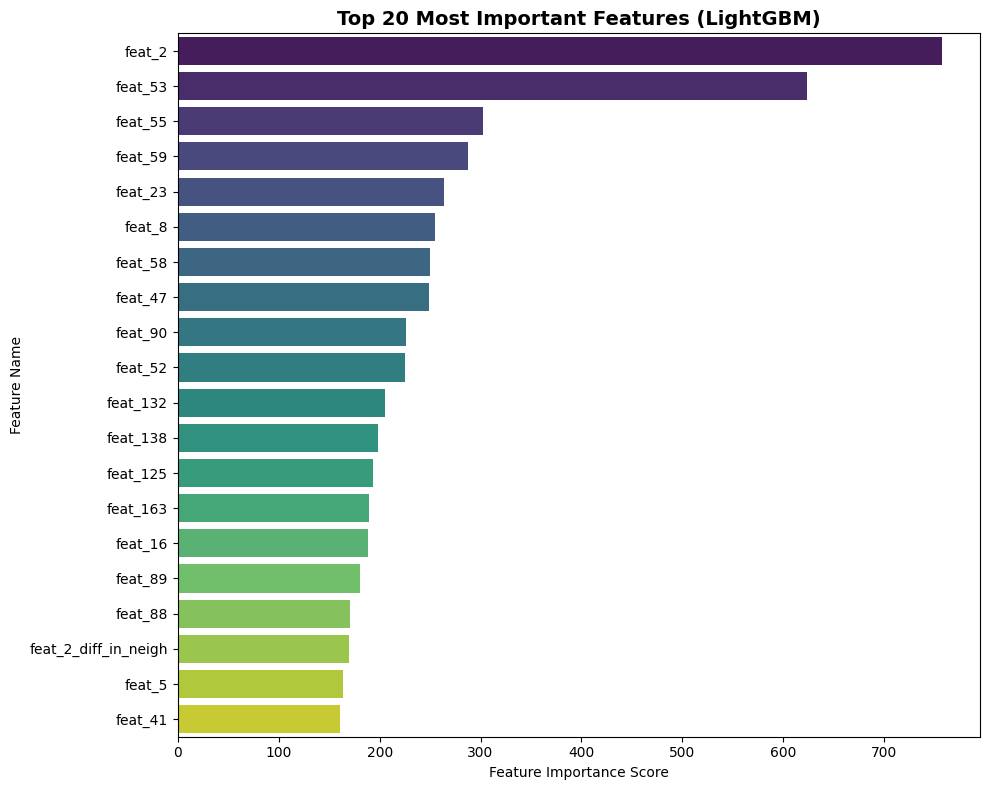

Top 10 Crucial Features:
Feature  Importance
 feat_2         757
feat_53         623
feat_55         302
feat_59         288
feat_23         264
 feat_8         255
feat_58         250
feat_47         249
feat_90         226
feat_52         225


In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature importances from trained LightGBM model
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': final_lgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot top 20 most important features
plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df.head(20),
    x='Importance',
    y='Feature',
    palette='viridis'
)
plt.title('Top 20 Most Important Features (LightGBM)', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()

# Print top 10 features text summary
print("Top 10 Crucial Features:")
print(importance_df.head(10).to_string(index=False))

In [80]:
import pandas as pd

sub = pd.read_csv('submission.csv')

# Verify shape, columns, missing values, and probability range
print("Shape:", sub.shape)
print("Columns:", list(sub.columns))
print("Null values:", sub.isnull().sum().sum())
print("Target Range:", sub['target'].min(), "-", sub['target'].max())
print("\nFirst 5 rows:")
print(sub.head())

Shape: (15329, 2)
Columns: ['index', 'target']
Null values: 0
Target Range: 0.000998108161002 - 1.0

First 5 rows:
   index    target
0      0  0.397606
1      1  0.644054
2      2  0.542071
3      3  0.440159
4      4  0.397978
